In [152]:
from datascience import *
import matplotlib.pylab as plt
import numpy as np
import plotly.express as px
import pandas as pd


# Operaciones group y pivot

In [186]:

# Crear la tabla con más filas
tabla_frutas = Table().with_columns(
    'Fruta', np.array(['manzana', 'pera', 'manzana', 'fresa', 'pera', 'fresa', 
                       'banano', 'mango', 'kiwi', 'banano', 'mango', 'fresa', 
                       'kiwi', 'pera', 'banano', 'manzana', 'pera', 'fresa', 
                       'mango', 'manzana']),
    'Color', np.array(['rojo', 'verde', 'verde', 'rojo', 'verde', 'rojo', 
                       'verde', 'naranja', 'verde', 'amarillo', 'naranja', 'rojo', 
                       'verde', 'verde', 'amarillo', 'rojo', 'verde', 'rojo', 
                       'naranja', 'rojo']),
    'Precio', np.array([2500, 3500, 2500, 4000, 3500, 4000, 
                              1500, 3000, 4500, 1500, 3000, 4000, 
                              4500, 3500, 1500, 2500, 3500, 4000, 
                              3000, 2500])
)

In [187]:
tabla_frutas.group(["Fruta", "Color"], np.mean)

Fruta,Color,Precio mean
banano,amarillo,1500
banano,verde,1500
fresa,rojo,4000
kiwi,verde,4500
mango,naranja,3000
manzana,rojo,2500
manzana,verde,2500
pera,verde,3500


In [188]:
tabla_frutas.pivot("Fruta", "Color")

Color,banano,fresa,kiwi,mango,manzana,pera
amarillo,2,0,0,0,0,0
naranja,0,0,0,3,0,0
rojo,0,4,0,0,3,0
verde,1,0,2,0,1,4


In [189]:
tabla_frutas.pivot("Fruta", "Color", values="Precio", collect=np.mean)

Color,banano,fresa,kiwi,mango,manzana,pera
amarillo,1500,0,0,0,0,0
naranja,0,0,0,3000,0,0
rojo,0,4000,0,0,2500,0
verde,1500,0,4500,0,2500,3500


# Libros

In [191]:
from datascience import *

# Crear la tabla con 20 libros
libros = Table().with_columns(
    'Titulo', make_array(
        'Cien Años de Soledad', 'El Quijote', '1984', 'Orgullo y Prejuicio', 'Crimen y Castigo', 
        'El Principito', 'Don Juan Tenorio', 'Matar a un Ruiseñor', 'La Odisea', 'El Gran Gatsby',
        'Fahrenheit 451', 'La Metamorfosis', 'El Retrato de Dorian Gray', 'Hamlet', 'Macbeth',
        'La Ilíada', 'El Señor de los Anillos', 'Drácula', 'Los Miserables', 'La Divina Comedia'),
    
    'Autor', make_array(
        'Gabriel García Márquez', 'Miguel de Cervantes', 'George Orwell', 'Jane Austen', 'Fiódor Dostoyevski', 
        'Antoine de Saint-Exupéry', 'José Zorrilla', 'Harper Lee', 'Homero', 'F. Scott Fitzgerald', 
        'Ray Bradbury', 'Franz Kafka', 'Oscar Wilde', 'William Shakespeare', 'William Shakespeare',
        'Homero', 'J. R. R. Tolkien', 'Bram Stoker', 'Victor Hugo', 'Dante Alighieri'),
    
    'Genero', make_array(
        'Ficción', 'Clásico', 'Ciencia Ficción', 'Romance', 'Clásico', 
        'Ficción', 'Clásico', 'Ficción', 'Clásico', 'Ficción',
        'Ciencia Ficción', 'Ficción', 'Clásico', 'Clásico', 'Clásico',
        'Clásico', 'Fantasía', 'Terror', 'Clásico', 'Clásico'),
    
    'Precio (COP)', make_array(
        45000, 60000, 40000, 38000, 52000, 
        35000, 30000, 45000, 32000, 42000,
        37000, 25000, 48000, 51000, 50000,
        30000, 70000, 35000, 68000, 63000),
    
    'Anio de Publicacion', make_array(
        1967, 1605, 1949, 1813, 1866,
        1943, 1844, 1960, 'Siglo VIII a.C.', 1925,
        1953, 1915, 1890, 1603, 1606,
        'Siglo VIII a.C.', 1954, 1897, 1862, 1320),
    
    'Calificacion (1-5)', make_array(
        4.8, 4.9, 4.7, 4.6, 4.8, 
        4.7, 4.4, 4.9, 4.6, 4.8,
        4.6, 4.5, 4.7, 4.9, 4.8,
        4.6, 4.9, 4.7, 4.9, 4.9)
)

In [192]:
libros.group("Genero", np.mean)

Genero,Titulo mean,Autor mean,Precio (COP) mean,Anio de Publicacion mean,Calificacion (1-5) mean
Ciencia Ficción,,,38500,,4.65
Clásico,,,48400,,4.75
Fantasía,,,70000,,4.9
Ficción,,,38400,,4.74
Romance,,,38000,,4.6
Terror,,,35000,,4.7


In [193]:
libros.where("Genero", are.equal_to("Clásico")).column("Precio (COP)").sum()

484000

# Joins

In [196]:
# Tabla de estudiantes con IDs y nombres
students = Table().with_columns(
    'ID', [1, 2, 3, 4],
    'Name', ['Alice', 'Bob', 'Charlie', 'David']
)

# Tabla de calificaciones con IDs y calificaciones
grades = Table().with_columns(
    'ID', [1, 2, 3, 5],
    'Grade', ['A', 'B', 'C', 'D']
)

# Realizar un join en la columna 'ID'
merged_table = students.join('ID', grades)

# Mostrar la tabla resultante
merged_table.show()


ID,Name,Grade
1,Alice,A
2,Bob,B
3,Charlie,C


# Ejercicios de clase árboles udea

## Árboles de la Universidad de Antioquia

En este ejercicio exploraremos un conjunto de datos con información sobre árboles localizados en el campus de la Universidad de Antioquia.  
Aplicaremos operaciones de filtrado, agrupamiento, exploración de especies y visualización geográfica.

1. Lee el archivo `arboles_udea_localizacion.csv` en una tabla llamada `arboles` y selecciona las columnas:
`"FAMILIA"`, `"Nombre común"`, `"Nombre científico"`, `"X"`, `"Y"`, `"ALTURA TOTAL"`, `"ALTURA DE COPA"`, `"DIAMETRO_MAYOR "`, `"DIAMETRO_MENOR"`.



2. Muestra los nombres de las columnas de la tabla.  
¿Qué función utilizas para hacerlo?



3. Filtra los árboles cuya **altura total** sea mayor a 20 metros.  
¿Cuántos árboles cumplen con esta condición?



4. Agrupa la tabla por la columna `"FAMILIA"` y calcula el **promedio de altura total** para cada familia.  
Muestra el resultado ordenado de mayor a menor.



5. ¿Qué familia tiene la **mayor altura promedio**?  
¿Y cuál tiene la **menor altura promedio**?


6. Muestra los nombres comunes de todas las especies presentes en el conjunto de datos.  
¿Qué función utilizas para obtener una lista sin repeticiones?



7. Filtra únicamente los árboles de la familia `"MORACEAE"` y realiza una tabla pivote (`pivot`) con la familia en las filas y el nombre común en las columnas.  
¿Qué observas en el resultado?


8. Convierte la tabla `arboles_udea` en un `DataFrame` de pandas con las columnas `"Y"`, `"X"` y `"Nombre común"`.  
Guárdalo en una variable llamada `data_arboles`.

```
import pandas as pd
data_arboles = arboles_udea.select('Y', 'X', 'Nombre común').to_df()
```

9. Utiliza `plotly.express` para crear un **mapa interactivo** con los puntos que representan la ubicación de los árboles.  
Cada punto debe mostrar el nombre común al pasar el cursor.  

- ¿Qué parámetro define el color de los puntos?  
- ¿Qué parámetro controla el nivel de zoom?  
- ¿Qué representa cada punto verde en el mapa?

Ayuda:

```python
fig = px.scatter_mapbox(
    data_arboles,
    lat='X',
    lon='Y',
    hover_name='Nombre común',
    color_discrete_sequence=['green'],
    zoom=16,
    height=600,
    title='Mapa interactivo de árboles sobre OpenStreetMap'
)
fig.update_layout(mapbox_style='open-street-map')
fig.show()
```  




10. Modifica el mapa cambiando el estilo de fondo (`mapbox_style`).  
¿Qué otros estilos gratuitos puedes usar además de `'open-street-map'`?








In [199]:
arboles = Table().read_table("arboles_udea_localizacion.csv")


In [200]:
arboles.labels


('Unnamed: 0',
 'FAMILIA',
 'Nombre común',
 'Nombre científico',
 'X',
 'Y',
 'NUMERO DE TALLOS',
 'CAP_1',
 'CAP_2',
 'CAP_3',
 'CAP_4',
 'CAP_5',
 'SUMATORIA CAP',
 'ALTURA TOTAL',
 'ALTURA DE COPA',
 'DIAMETRO_MAYOR ',
 'DIAMETRO_MENOR',
 'ORIENTACIÒN DE COPA (Punto Cardinal)')

In [201]:
arboles_udea = arboles.select("FAMILIA", "Nombre común","Nombre científico", "X", "Y",'ALTURA TOTAL',
 'ALTURA DE COPA',
 'DIAMETRO_MAYOR ',
 'DIAMETRO_MENOR',)


In [202]:
arboles_udea.where("ALTURA TOTAL", are.above(20))



FAMILIA,Nombre común,Nombre científico,X,Y,ALTURA TOTAL,ALTURA DE COPA,DIAMETRO_MAYOR,DIAMETRO_MENOR
MORACEAE,Falso laurel,Ficus benjamina,6.2691,-75.5665,24,7.5,42.6,38.5
MORACEAE,Falso laurel,Ficus benjamina,6.26891,-75.5666,25,10,45.8,36.4
MORACEAE,Falso laurel,Ficus benjamina,6.26881,-75.5666,24,4,34.4,26.5
MORACEAE,Falso laurel,Ficus benjamina,6.2686,-75.5666,25,8,35.2,28.9
MORACEAE,Falso laurel,Ficus benjamina,6.26842,-75.5667,27,9,41.6,36.4
MORACEAE,Falso laurel,Ficus benjamina,6.26832,-75.5667,26,4,35.2,28.4
MORACEAE,Falso laurel,Ficus benjamina,6.26817,-75.5667,26,9,32.25,28.6
MORACEAE,Falso laurel,Ficus benjamina,6.26798,-75.5668,25,8,45.6,34.9
MORACEAE,Falso laurel,Ficus benjamina,6.26781,-75.5668,21,12,36.5,29.8
MORACEAE,Falso laurel,Ficus benjamina,6.26716,-75.567,26,7.5,32.15,25.6


In [203]:
arboles_udea.group("FAMILIA", np.mean).select("FAMILIA","ALTURA TOTAL mean" ).sort("ALTURA TOTAL mean")



FAMILIA,ALTURA TOTAL mean
CYCADACEAE,0.992857
SOLANACEAE,2.85745
FAGACEAE,3.025
ZYGOPHYLLACEAE,3.03594
APOCYNACEAE,3.64815
CHRYSOBALANACEAE,3.9
VERBENACEAE,3.96364
RUTACEAE,4.07447
MELASTOMATACEAE,4.1
CAPPARACEAE,4.1


In [204]:

familia_mean_altura = arboles_udea.group("FAMILIA", np.mean).select("FAMILIA","ALTURA TOTAL mean" ).sort("ALTURA TOTAL mean")
familia_mean_altura.sort("ALTURA TOTAL mean", descending=True).show(50)


FAMILIA,ALTURA TOTAL mean
MORACEAE,19.1281
ARAUCARIACEAE,16.5714
ANACARDIACEAE,14.7288
OLEACEAE,14.7224
MELIACEAE,13.3057
POLYGONACEAE,12.5409
URTICACEAE,12.1426
COMBRETACEAE,11.5367
CALOPHYLLACEAE,11.1143
CASUARINACEAE,10.9


In [205]:


np.unique(arboles_udea.column("Nombre común"))


array(['Abarco', 'Acacia amarilla', 'Acacia amarilla (1)',
       'Acacia ferrugínea', 'Acacia mangium', 'Acacia roja',
       'Acacia rosada', 'Aceite María', 'Achiote', 'Aegiphila', 'Aguacate',
       'Aguacatillo', 'Alcanfor', 'Algarrobo', 'Allophyllus', 'Alma negra',
       'Almanegra', 'Almendro', 'Almirajo', 'Almirajó', 'Annona sp.',
       'Araucaria', 'Arazá', 'Arizá', 'Arroz con coco', 'Astrocarium',
       'Atalea sp.', 'Azahar de la india', 'Azuceno', 'Azuceno de monte',
       'Bala de cañón', 'Balaustre', 'Balsamo', 'Barbasco', 'Barrigón',
       'Bischofia', 'Brownea ucayalina', 'Búcaro', 'Caballero de la noche',
       'Cabo de hacha', 'Cacao', 'Cacao de monte', 'Caimito',
       'Calistemo blanco', 'Calistemo rojo', 'Camajón',
       'Canastilla rosada', 'Canelo', 'Canime', 'Canistel', 'Caobo',
       'Capitancillo', 'Capote', 'Caracolí', 'Carambolo', 'Carbonero',
       'Carbonero ', 'Carbonero (2)', 'Carbonero de pluma',
       'Carbonero zorro', 'Cariseco', 'Carmín',

In [206]:

arboles_udea.where("FAMILIA", are.equal_to("MORACEAE")).pivot("FAMILIA","Nombre común")


Nombre común,MORACEAE
Dinde,1
Falso caucho,7
Falso laurel,54
Ficus,1
Ficus pandurata,3
Sande Mora,4
Árbol del pan,3


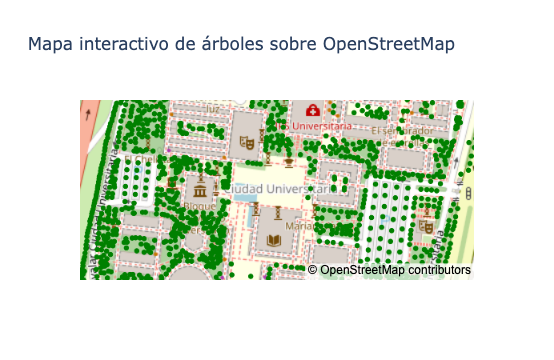

In [207]:

data_arboles = arboles_udea.select('Y', 'X', 'Nombre común').to_df()
# Crear mapa
fig = px.scatter_mapbox(
    data_arboles,
    lat='X',
    lon='Y',
    hover_name='Nombre común',
    color_discrete_sequence=['green'],
    zoom=16,
    height=600,
    title='Mapa interactivo de árboles sobre OpenStreetMap'
)
# Configurar estilo base (gratuito)
fig.update_layout(mapbox_style='open-street-map')
fig.show()